# 📘 연습문제

## 문제1

### blood_pressure 데이터셋은 부인 15명을 대상으로 평상시 혈압을 측정한 뒤, 이들에게 이 피임약을 일정 기간 복용하게 한 후 이들의 혈압을 다시 측정한 결과를 기록한 데이터이다. 이 데이터를 통해 피임약 복용이 혈압에 영향을 주는지 분석하라.

In [61]:
from hossam import load_data
from pandas import melt, DataFrame, concat
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import numpy as np
import seaborn as sb
from math import sqrt
from scipy.stats import t, normaltest, bartlett, levene, ttest_rel,mannwhitneyu,ttest_ind
from statannotations.Annotator import Annotator
from sklearn.preprocessing import StandardScaler

In [3]:
my_dpi = 200
fpath = "./NotoSansKR-Regular.ttf"
fm.fontManager.addfont(fpath)
fprop = fm.FontProperties(fname=fpath) # 폰트의 속성을 읽어옴
fname = fprop.get_name() # 읽어온 속성에서 폰트의 이름만 추출
plt.rcParams['font.family'] = fname
plt.rcParams['font.size'] = 10
plt.rcParams['axes.unicode_minus'] = False

In [4]:
origin = load_data('blood_pressure')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab10_/blood_pressure.xlsx
[desc] 부인 15명을 대상으로 평상시 혈압을 측정한 뒤, 이들에게 이 피임약을 일정 기간 복용하게 한 후 이들의 혈압을 다시 측정한 결과를 기록한 데이터 (출처: 방송통신대학교 통계학개론)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (15, 2)
열 개수: 2
행 개수: 15

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   복용전     15 non-null     int64
 1   복용후     15 non-null     int64
dtypes: int64(2)
memory usage: 372.0 bytes
None


,복용전,복용후
0,70,68
1,80,72
2,72,62
3,76,70
4,76,58


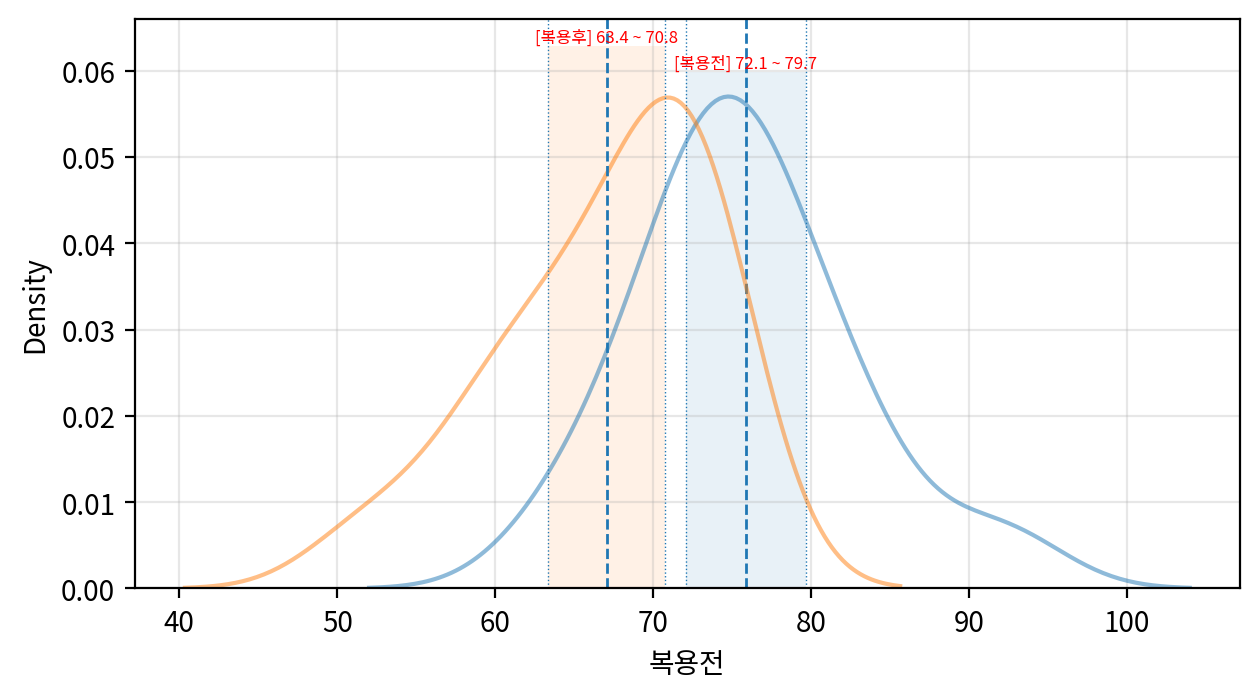

In [5]:
# 확인할 데이터
data = origin[['복용전', '복용후']]

# 1) 그래프 초기화
width_px = 1280  # 그래프 가로 크기
height_px = 720  # 그래프 세로 크기
rows = 1         # 그래프 행 수
cols = 1         # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

for c in data.columns:
    # KDE Plot 그리기
    sb.kdeplot(data=data, x=c, fill=False, alpha=0.5)

    # 신뢰구간 계산
    max_val = data[c].max()          # 최대값 (필요 시 사용)
    clevel = 0.95                    # 신뢰수준
    dof = len(data[c]) - 1           # 자유도
    sp_mean = data[c].mean()         # 표본평균
    sp_std = data[c].std(ddof=1)     # 표본표준편차
    sp_std_error = sp_std / sqrt(len(data[c]))  # 표본표준오차

    cmin, cmax = t.interval(
        clevel,
        dof,
        loc=sp_mean,
        scale=sp_std_error
    )

    # 신뢰구간 경계선
    ax.axvline(cmin, linestyle=':', linewidth=0.5)
    ax.axvline(cmax, linestyle=':', linewidth=0.5)

    # 평균 및 신뢰구간 영역 표시
    ymin, ymax = ax.get_ylim()
    ax.fill_between([cmin, cmax], 0, ymax, alpha=0.1)
    ax.axvline(sp_mean, linestyle='--', linewidth=1)

    # 텍스트 표시
    ax.text(
        x=(cmax - cmin) / 2 + cmin,
        y=ymax,
        s="[%s] %0.1f ~ %0.1f" % (c, cmin, cmax),
        horizontalalignment="center",
        verticalalignment="bottom",
        fontdict={"size": 6, "color": "red"}
    )

# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3)  # 배경 격자 표시

# 4) 출력
plt.tight_layout()
plt.show()
plt.close()


두 그룹의 커널 밀도 함수 그래프의 모양이 정규분포를 띄고 있으며, 두 그룹의 데이터 분포가 서로 다르다고 할 수 있다.
또한 두 그룹의 표본 평균이 신뢰구간에 포함되어 있으므로 데이터가 정삼범위에 있다고 할 수 있다.

In [7]:
s, p = ttest_rel(origin['복용전'], origin['복용후'],alternative='greater')
"statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택".format(s, p, "대립" if p <= 0.05 else "귀무")

'statistic: 3.105, p-value: 0.004, 대립가설 채택'

차이값(복용전−복용후)에 대한 t 통계량은 3.105이고, 이에 대응되는 유의확률은 0.004로 유의수준 0.05보다 작다(p < 0.05)
따라서 귀무가설을 기각하고 대립가설을 채택한다.
즉, 복용전 평균 혈압이 복용후 평균 혈압보다 통계적으로 유의하게 높으므로, 약 복용 후 혈압이 감소한 것으로 볼 수 있다.

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

복용전 vs. 복용후: t-test independent samples, P_val:1.346e-03 t=3.561e+00


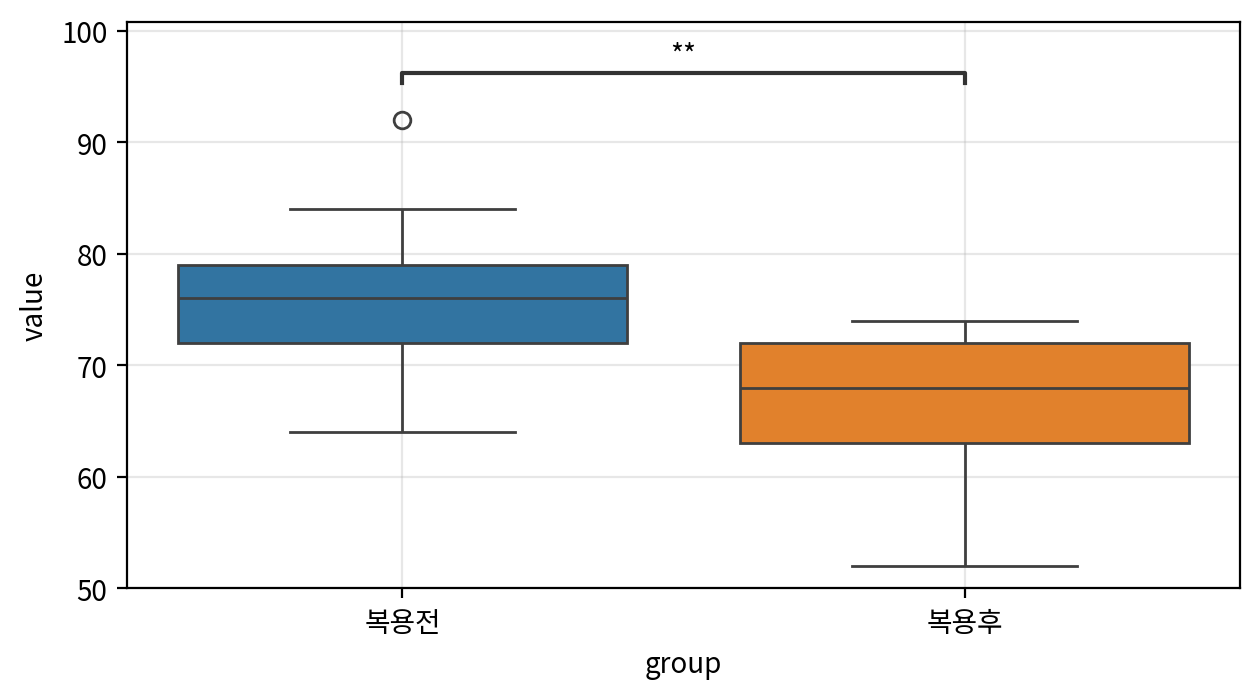

In [8]:
# 검정할 데이터 필드명
fields = ['복용전', '복용후']
# 검정 방법
# `t-test_ind`, `t-test_paired`, `t-test_welch`,
#  `Mann-Whitney`,`Mann-Whitney-gt`, `Mann-Whitney-ls`, `Levene`, `Wilcoxon`,`Kruskal`
test_method = 't-test_paired'
# 데이터 재배치
df = melt(origin[fields], value_vars=fields, var_name='group',value_name='value')

# 1) 그래프 초기화
width_px = 1280 # 그래프 가로 크기
height_px = 720 # 그래프 세로 크기
rows = 1 # 그래프 행 수
cols = 1 # 그래프 열 수
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
# 2) BoxPlot 그리기
sb.boxplot(data=df, x='group', y='value', hue='group')
annotator = Annotator(ax, data=df, x='group', y='value',pairs=[('복용전', '복용후')])
annotator.configure(test='t-test_ind')
annotator.apply_and_annotate()
# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3) # 배경 격자 표시
# 4) 출력
plt.tight_layout() # 여백 제거
plt.show() # 그래프 화면 출력
plt.close() # 그래프 작업 종료

In [ ]:
origin = load_data('df_cats')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab10_/cookie_cats.xlsx
[desc] 어느 모바일 게임의 버전에 따른 유저별 총 플레이 시간을 조사한 데이터 (출처: 방송통신대학교 통계학개론)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (90189, 3)
열 개수: 3
행 개수: 90189

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 2.1+ MB
None


,userid,version,sum_gamerounds
0,116,A,3
1,337,A,38
2,377,B,165
3,483,B,1
4,488,B,179


In [11]:
origin.describe()

,userid,sum_gamerounds
count,9.018900e+04,90189.000000
mean,4.998412e+06,51.872457
std,2.883286e+06,195.050858
min,1.160000e+02,0.000000
25%,2.512230e+06,5.000000
50%,4.995815e+06,16.000000
75%,7.496452e+06,51.000000
max,9.999861e+06,49854.000000


In [65]:
s, p = normaltest(origin['sum_gamerounds'])
"statistic: {0:.3f}, p-value: {1:.3f}, 정규성 충족 여부: {2}".format(s,p, p > 0.05)

'statistic: 431864.655, p-value: 0.000, 정규성 충족 여부: False'

In [41]:
Q1 = origin['sum_gamerounds'].quantile(0.25)
Q3 = origin['sum_gamerounds'].quantile(0.75)
IQR = Q3 - Q1

up = Q3 + 1.5 * IQR
up

np.float64(120.0)

In [56]:
df = origin[origin['sum_gamerounds'] <= up].copy()
df['version'].value_counts()

version
B    40374
A    39638
Name: count, dtype: int64

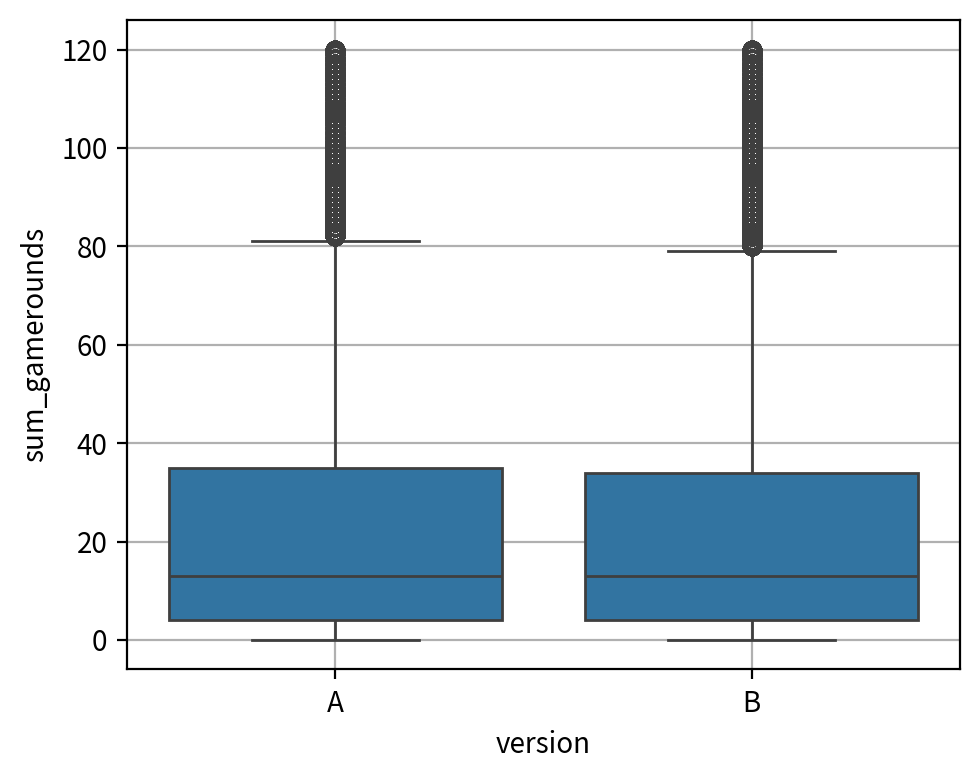

In [45]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1000
height_px = 800
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

#2) 그래프 그리기 -> seaborn 사용
sb.boxplot(data=df, x='version', y='sum_gamerounds')

#3) 그래프 꾸미기
ax.grid(True)

# 4) 출력

plt.tight_layout()
#plt.savefig("myplot.png", dpi=my_dpi)
plt.show() # 그래프 화면 출력
plt.close()

In [57]:
# 1) A, B 그룹의 sum_gamerounds만 각각 뽑기
A = df.loc[df['version'] == 'A', 'sum_gamerounds'].reset_index(drop=True)
B = df.loc[df['version'] == 'B', 'sum_gamerounds'].reset_index(drop=True)

df2 = concat([A, B], axis=1)
df2.columns = ['A', 'B']
df3 = df2.dropna()
df3.head()


,A,B
0,3.0,1
1,38.0,2
2,0.0,108
3,0.0,3
4,39.0,30


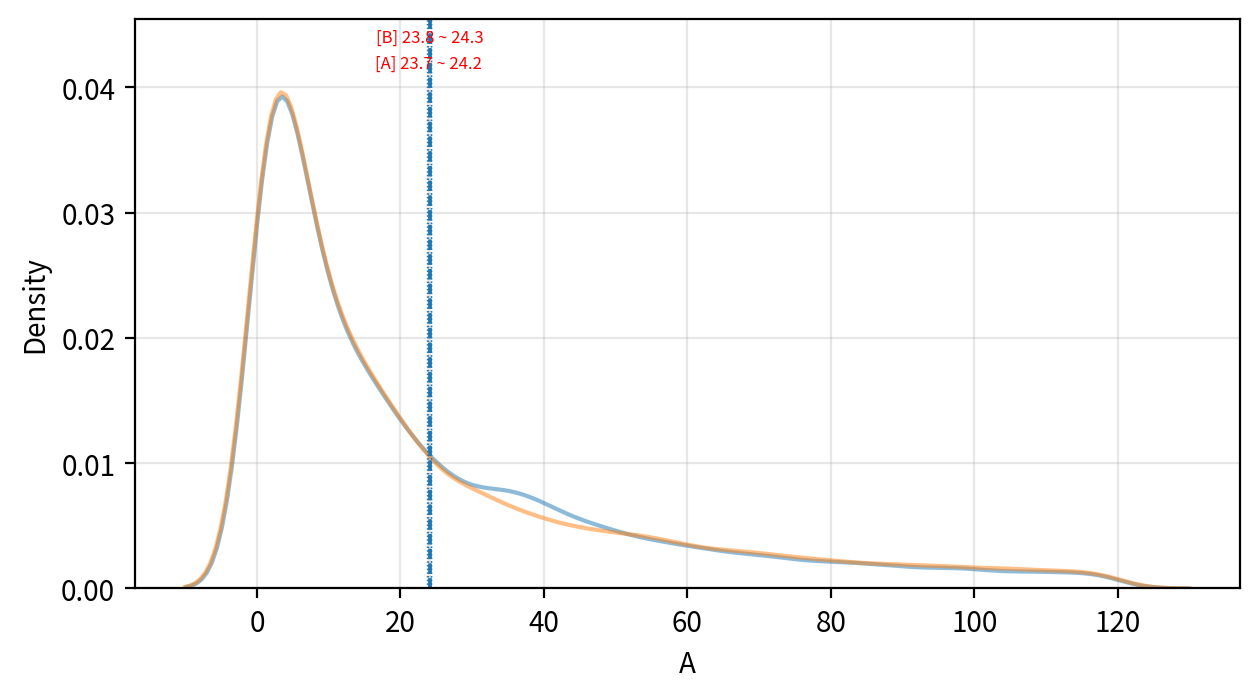

In [58]:
# 확인할 데이터
data = df3[['A', 'B']]

# 1) 그래프 초기화
width_px = 1280  # 그래프 가로 크기
height_px = 720  # 그래프 세로 크기
rows = 1         # 그래프 행 수
cols = 1         # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

for c in data.columns:
    # KDE Plot 그리기
    sb.kdeplot(data=data, x=c, fill=False, alpha=0.5)

    # 신뢰구간 계산
    max_val = data[c].max()          # 최대값 (필요 시 사용)
    clevel = 0.95                    # 신뢰수준
    dof = len(data[c]) - 1           # 자유도
    sp_mean = data[c].mean()         # 표본평균
    sp_std = data[c].std(ddof=1)     # 표본표준편차
    sp_std_error = sp_std / sqrt(len(data[c]))  # 표본표준오차

    cmin, cmax = t.interval(
        clevel,
        dof,
        loc=sp_mean,
        scale=sp_std_error
    )

    # 신뢰구간 경계선
    ax.axvline(cmin, linestyle=':', linewidth=0.5)
    ax.axvline(cmax, linestyle=':', linewidth=0.5)

    # 평균 및 신뢰구간 영역 표시
    ymin, ymax = ax.get_ylim()
    ax.fill_between([cmin, cmax], 0, ymax, alpha=0.1)
    ax.axvline(sp_mean, linestyle='--', linewidth=1)

    # 텍스트 표시
    ax.text(
        x=(cmax - cmin) / 2 + cmin,
        y=ymax,
        s="[%s] %0.1f ~ %0.1f" % (c, cmin, cmax),
        horizontalalignment="center",
        verticalalignment="bottom",
        fontdict={"size": 6, "color": "red"}
    )

# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3)  # 배경 격자 표시

# 4) 출력
plt.tight_layout()
plt.show()
plt.close()


In [60]:
data = df3[['A', 'B']]  # 검사하려는 데이터 추출

equal_var_fields = []
normal_dist = True
report = []

for c in data.columns:
    s, p = normaltest(data[c])
    normalize = p > 0.05
    report.append({
        "field": c,
        "statistic": s,
        "p-value": p,
        "result": normalize
    })
    normal_dist = normal_dist and normalize

# 변수가 두 개 이상인 경우 등분산성 확인
if len(data.columns) > 1:
    if normal_dist:
        n = "Bartlett"  # 정규성을 충족할 경우의 검정방법
        s, p = bartlett(*data.values.T)  # 모든 컬럼의 데이터를 한번에 전달
    else:
        n = "Levene"  # 정규성을 충족하지 않을 경우의 검정방법
        s, p = levene(*data.values.T, center='median')  # 모든 컬럼의 데이터를 한번에 전달

    report.append({
        "field": n,
        "statistic": s,
        "p-value": p,
        "result": p > 0.05
    })

report_df = DataFrame(report).set_index('field')
report_df


,statistic,p-value,result
field,,,
A,10187.627365,0.000000,False
B,10055.740508,0.000000,False
Levene,3.051606,0.080661,True


In [67]:
s, p = ttest_ind(df3['A'], df3['B'], alternative='two-sided', equal_var=False)
"statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택".format(s, p, "대립" if p <= 0.05 else "귀무")

'statistic: -0.552, p-value: 0.581, 귀무가설 채택'

p-value가 0.05보다 크므로(P>=0.05) 대립 가설 대신 귀무가설을 채택한다.

# 추가 문제 입니다.

adult_height• 데이터셋은 성인 30명의 성별(sex)과 신장(height) 데이터이다.다음 물음에 답하시오.
(1) 귀무가설과 대립가설은 각각 무엇인가?
(2) (1)번의 가설을 검정하고 결과를 해석하시오.
지금까지 학습한 세 가지 검정방법 중에서 어떤 방법을 사용해야 하는지 판단해서 진행하세요.

In [82]:
origin = load_data('adult_height')
print("\n===== 데이터 크기 확인 =====")
print(f"데이터셋 크기: {origin.shape}")
print(f"열 개수: {origin.shape[1]}")
print(f"행 개수: {origin.shape[0]}")
print("\n===== 타입확인 =====")
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/lab10_/adult_height.xlsx
[desc] 성인 30명의 성별(sex), 신장(height) 데이터 (출처: 방송통신대학교 바이오통계학)
[!] Cannot read metadata

===== 데이터 크기 확인 =====
데이터셋 크기: (30, 2)
열 개수: 2
행 개수: 30

===== 타입확인 =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   sex     30 non-null     object
 1   height  30 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 612.0+ bytes
None


,sex,height
0,F,161
1,F,160
2,F,164
3,F,172
4,F,157


In [ ]:
origin['sex'].value_counts()

sex
F    15
M    15
Name: count, dtype: int64

귀무 가설은 해당 하는 주장의 가설의 차이가 없다 라는 뜻의 의미를 가진다 즉 해당 하는 가설에 바뀌는 점이 없다는 뜻이다.
반대로 대립 가설을 해당 하는 주장의 차이가 있다 라는 뜻을 가지며 해당 가설의 주장에 대립 즉 반대되는 의미를 가진다는 뜻이다.

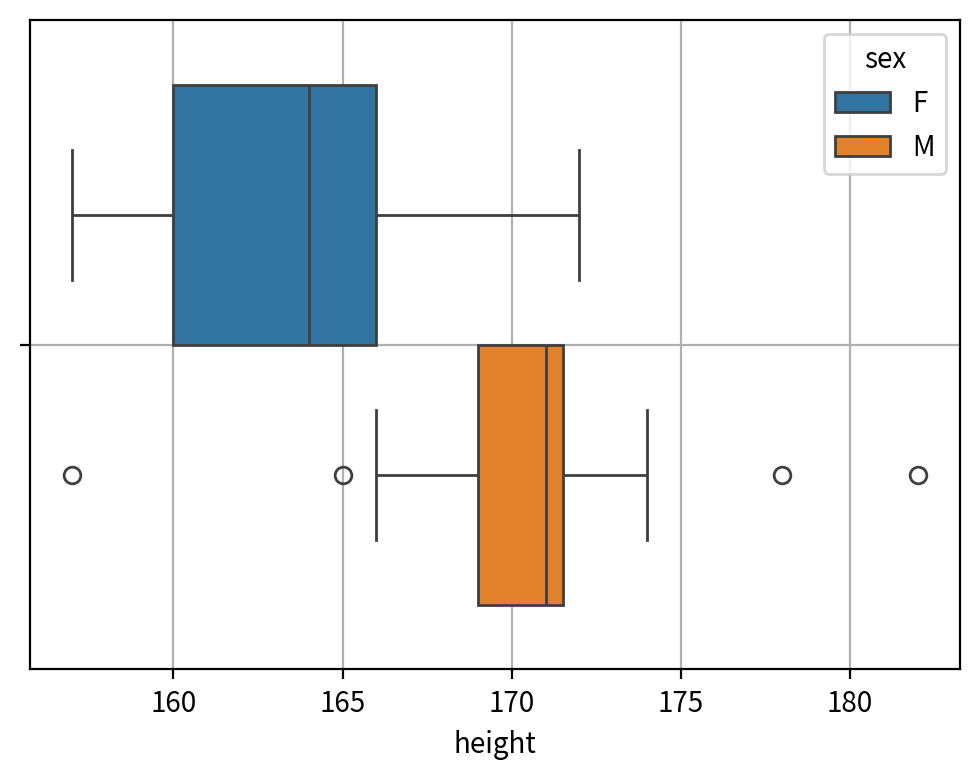

In [83]:
# 1) 그래프 초기화 (캔바스(fig)와 도화지(ax) 준비하기)
width_px = 1000
height_px = 800
rows = 1
cols = 1
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

#2) 그래프 그리기 -> seaborn 사용
sb.boxplot(data=origin, x='height',hue='sex')

#3) 그래프 꾸미기
ax.grid(True)

plt.tight_layout()
#plt.savefig("myplot.png", dpi=my_dpi)
plt.show() # 그래프 화면 출력
plt.close()

해당 박스 플롯을 보았을 떄 남녀의 키 차이는 남자가 큰것으로 확인이 된다.
여자는 키의 분포가 넓게 퍼져있지만 남자는 좁게 형성이 되어있다. 또한 남자는 특정 이상치가 포함이 되어 있다.

In [ ]:
### 정규성 확인

In [ ]:
df = []
for i in origin['sex'].unique():
    df.append(origin.query(f"sex == '{i}'")['height'].reset_index(drop=True))

df2 = concat(df, axis=1)
df2.columns = origin['sex'].unique()
df2

,F,M
0,161,166
1,160,157
2,164,171
3,172,174
4,157,170
5,164,172
6,166,165
7,169,182
8,166,170
9,164,168


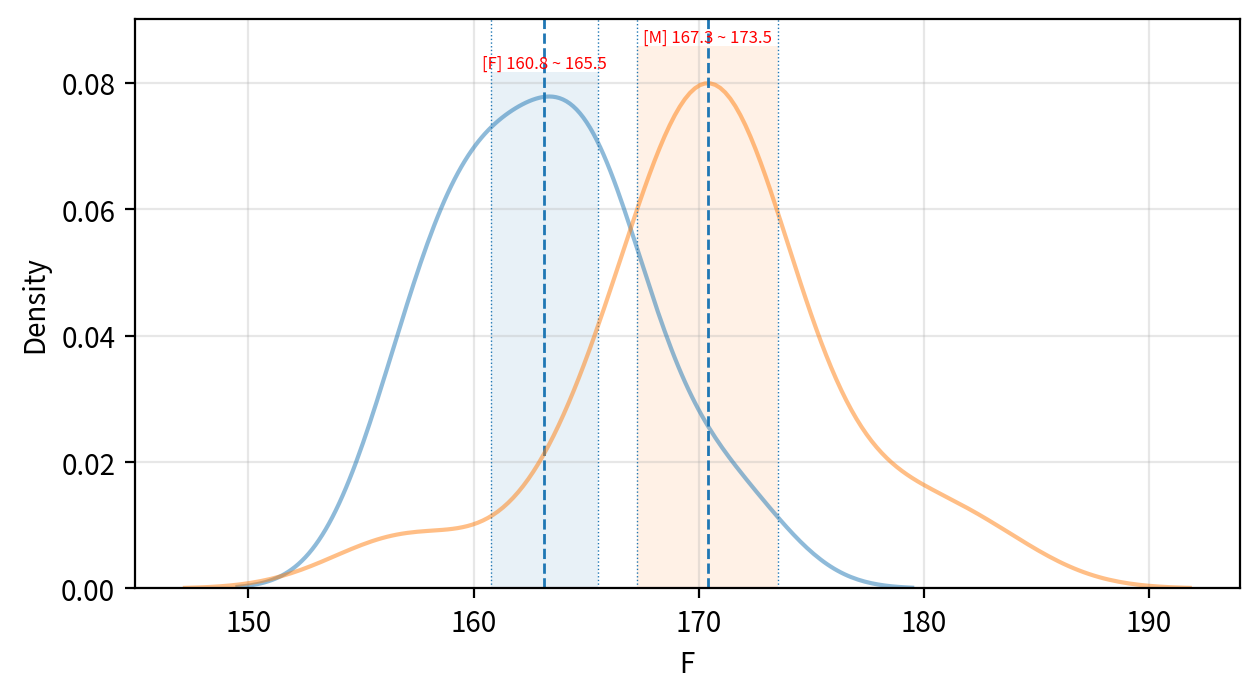

In [95]:
# 확인할 데이터
data = df2[['F', 'M']]

# 1) 그래프 초기화
width_px = 1280  # 그래프 가로 크기
height_px = 720  # 그래프 세로 크기
rows = 1         # 그래프 행 수
cols = 1         # 그래프 열 수

figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)

for c in data.columns:
    # KDE Plot 그리기
    sb.kdeplot(data=data, x=c, fill=False, alpha=0.5)

    # 신뢰구간 계산
    max_val = data[c].max()          # 최대값 (필요 시 사용)
    clevel = 0.95                    # 신뢰수준
    dof = len(data[c]) - 1           # 자유도
    sp_mean = data[c].mean()         # 표본평균
    sp_std = data[c].std(ddof=1)     # 표본표준편차
    sp_std_error = sp_std / sqrt(len(data[c]))  # 표본표준오차

    cmin, cmax = t.interval(
        clevel,
        dof,
        loc=sp_mean,
        scale=sp_std_error
    )

    # 신뢰구간 경계선
    ax.axvline(cmin, linestyle=':', linewidth=0.5)
    ax.axvline(cmax, linestyle=':', linewidth=0.5)

    # 평균 및 신뢰구간 영역 표시
    ymin, ymax = ax.get_ylim()
    ax.fill_between([cmin, cmax], 0, ymax, alpha=0.1)
    ax.axvline(sp_mean, linestyle='--', linewidth=1)

    # 텍스트 표시
    ax.text(
        x=(cmax - cmin) / 2 + cmin,
        y=ymax,
        s="[%s] %0.1f ~ %0.1f" % (c, cmin, cmax),
        horizontalalignment="center",
        verticalalignment="bottom",
        fontdict={"size": 6, "color": "red"}
    )

# 3) 그래프 꾸미기
ax.grid(True, alpha=0.3)  # 배경 격자 표시

# 4) 출력
plt.tight_layout()
plt.show()
plt.close()


In [96]:
# 검사하려는 데이터 추출
data = df2[['F', 'M']]

equal_var_fields = []
normal_dist = True
report = []

# 각 변수별 정규성 검정
for c in data.columns:
    s, p = normaltest(data[c])
    normalize = p > 0.05

    report.append({
        "field": c,
        "statistic": s,
        "p-value": p,
        "result": normalize
    })

    normal_dist = normal_dist and normalize

# 변수가 두 개 이상인 경우 등분산성 확인
if len(data.columns) > 1:
    if normal_dist:
        n = "Bartlett"  # 정규성을 충족할 경우의 검정 방법
        # 모든 컬럼의 데이터를 한 번에 전달
        s, p = bartlett(*data.values.T)
    else:
        n = "Levene"    # 정규성을 충족하지 않을 경우의 검정 방법
        # 모든 컬럼의 데이터를 한 번에 전달
        s, p = levene(*data.values.T, center='median')

    report.append({
        "field": n,
        "statistic": s,
        "p-value": p,
        "result": p > 0.05
    })

# 결과를 DataFrame으로 정리
report_df = DataFrame(report).set_index('field')
report_df


,statistic,p-value,result
field,,,
F,0.478834,0.787086,True
M,3.245853,0.197320,True
Bartlett,2.055126,0.151695,True


정규성과 등분산성이 충족한다.

In [ ]:
s, p = ttest_ind(df2['F'], df2['M'],alternative='greater')
"statistic: {0:.3f}, p-value: {1:.3f}, {2}가설 채택".format(s, p, "대립" if p <= 0.05 else "귀무")

'statistic: -3.976, p-value: 1.000, 귀무가설 채택'

p-value가 0.05보다 크므로(P > 0.05) 귀무가설을 채택한다
즉 남자의 키 평균은 여자의 키 평균보다 큰 것으로 확인된다.

서로 다른 두개의 그룹 간 평균의 차이가 유믜미한지 여부를 판단하기 때문에
독립 표본 T-검정 방법을 사용하였다.

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

F vs. M: t-test independent samples, P_val:4.477e-04 t=-3.976e+00


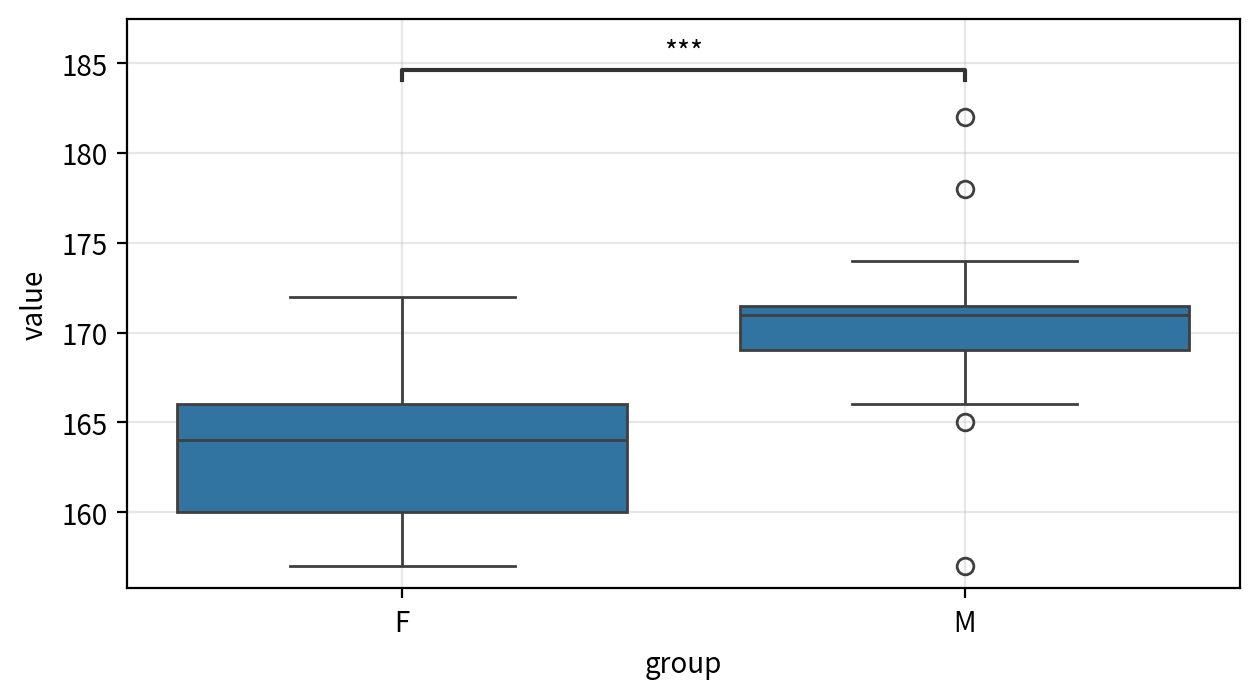

In [101]:
df3 = df2.melt(var_name='group', value_name='value')

# 1) 그래프 초기화
width_px = 1280
height_px = 720
figsize = (width_px / my_dpi, height_px / my_dpi)
fig, ax = plt.subplots(figsize=figsize, dpi=my_dpi)

# 2) BoxPlot
sb.boxplot(data=df3, x='group', y='value')

# 3) Annotator
annotator = Annotator(
    ax,
    data=df3,
    x='group',
    y='value',
    pairs=[('F','M')]
)
annotator.configure(test='t-test_ind')
annotator.apply_and_annotate()

# 4) 꾸미기 & 출력
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()
